## ECON4060H 2021 Winter
## Quantitative Methods in Economics
### Week 10 Machine Learning I: Regularized linear regressions
### Shutao Cao

**Credit**: Some of the code snippets in this notebook were adapted from 

## Initial Setup
First, import a few common modules.

In [2]:
import sys
import numpy as np
import pandas as pd
import sklearn
import os
import matplotlib as mpl
import matplotlib.pyplot as plt


assert sys.version_info >= (3, 5)
assert sklearn.__version__ >= "0.20"
np.random.seed(42)
%matplotlib inline
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
lecture_id = "05machineLearning"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, lecture_id,"images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Data preparation
We read in the data file and process it. Data is a random sample of the Labor Force Survey (LFS) 2015. The data have information on employment and social demographics. Variable list is in this [codebook](codebook_LFS2015Sample.md).


In [3]:
#----read in LFS 2015 random sample, data is created by LFS2015.do
filename='LFS2015Sample.csv'
lfs = pd.read_csv(filename, index_col=None)
# create dummy variables in pandas
# there are better ways to do this in sklearn.preprocessing: OneHotEncoder, LabelBinarizer
#province dummy [24, 35, 59, 48, 47, 12, 46, 13]
#occupation dummy: selected occupations [2, 4, 5,6,9,13,17,20,23]
# naics: 6,7,10,11,14,16,17,19,20,21
# and a list of other variables
lfs.rename(columns={'naics21': 'naics'}, inplace=True)
vlist = ['province','occup','estsize','firmsize','naics','empclass','educ','marstat']
for x in vlist:
    lfs[x] = lfs[x].astype(pd.Int64Dtype())
    y = pd.get_dummies(lfs[x], prefix="%s" % x, prefix_sep="", dummy_na=False, sparse=False, drop_first=False, dtype=None)
    lfs = pd.concat([lfs, y], axis=1)
# create age squared
lfs['lnhrlyearn'] = np.log(lfs['hrlyearn'])
lfs['ageGrp2'] = lfs['ageGrp']*lfs['ageGrp']
lfs['ones'] = 1.0
lfs.columns

Index(['UTOTHRS', 'ATOTHRS', 'tenure', 'hrlyearn', 'year', 'month', 'naics',
       'empclass', 'empstat', 'permemploy',
       ...
       'educ5', 'marstat1', 'marstat2', 'marstat3', 'marstat4', 'marstat5',
       'marstat6', 'lnhrlyearn', 'ageGrp2', 'ones'],
      dtype='object', length=106)

## Linear regression

Dependent variable is logarithm of hourly earnings. We need to drop those observations with missing hourly earnings

In [4]:
lfs2 = lfs.dropna()
# dependent variables
Y = lfs2['lnhrlyearn']
# independent variables
X = lfs2[['ATOTHRS', 'tenure', 'permemploy', 'fullTime', 'union',
       'occup2', 'occup4', 'occup5', 'occup6', 'occup9', 'occup13', 'occup17',
       'occup20', 'occup23', 'estsize1', 'estsize2', 'estsize3', 'naics6', 
       'naics7', 'naics10', 'naics11', 'naics14', 'naics16', 'naics17', 'naics19',
       'naics20', 'naics21', 'empclass1', 'educ1', 'educ2', 'educ3', 'educ4',
       'marstat1', 'marstat6','male','ageGrp','ageGrp2']]
X_b = pd.concat([lfs2['ones'], X],axis=1)

In [5]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, Y)
lin_reg.intercept_, lin_reg.coef_

(2.932653751153499,
 array([ 0.00068076,  0.0008375 ,  0.09750948,  0.07240138,  0.06776068,
         0.35196092, -0.01467364, -0.12014158,  0.20526108,  0.03166754,
        -0.14990804, -0.20772077,  0.10081381,  0.03017551, -0.17368494,
        -0.11420846, -0.07880195,  0.14514581, -0.04580625, -0.12928331,
        -0.02291934,  0.07490512, -0.00581551, -0.04413674, -0.18471067,
        -0.06457634,  0.02464642, -0.13011096, -0.27592139, -0.24392761,
        -0.18027825, -0.06168215,  0.02125868, -0.04516265,  0.08245235,
         0.10257462, -0.00819211]))

In [6]:
X_new = X.iloc[1:3,:]
Y_new = lin_reg.predict(X_new)
print('X_new',X_new)
print('Y_new',Y_new)

X_new    ATOTHRS  tenure  permemploy  fullTime  union  occup2  occup4  occup5  \
3     20.0   167.0           1       0.0    0.0       0       0       0   
6     37.5     3.0           1       1.0    0.0       0       0       0   

   occup6  occup9  ...  empclass1  educ1  educ2  educ3  educ4  marstat1  \
3       0       0  ...          1      0      0      1      0         1   
6       1       0  ...          1      0      0      1      0         1   

   marstat6  male  ageGrp  ageGrp2  
3         0     0       8       64  
6         0     1       8       64  

[2 rows x 37 columns]
Y_new [2.97299057 3.42549043]


## Linear regression solution by Stochastic Gradient Descent

In [7]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1, random_state=42)
sgd_reg.fit(X, Y.ravel())

SGDRegressor(eta0=0.1, penalty=None, random_state=42)

In [8]:
sgd_reg.intercept_, sgd_reg.coef_

(array([1.20209007e+11]),
 array([-1.00810332e+11, -1.94593280e+11,  2.12461589e+10, -5.21448426e+10,
         2.21676095e+11, -4.19062738e+11, -2.98905451e+11,  2.13345571e+11,
        -2.68651443e+11, -9.97917779e+10,  7.03313983e+10, -3.33663718e+09,
         1.48616675e+11,  1.18427074e+09, -1.28980439e+11, -1.25583356e+11,
         1.50203624e+11,  3.57199339e+11, -5.06458066e+10, -5.33571526e+10,
        -1.25829149e+11,  1.11162959e+11, -8.89009970e+10, -7.65727461e+10,
         1.38162516e+11,  2.09072137e+11, -3.73761199e+10,  4.96341995e+10,
        -1.27489349e+11,  9.56671056e+10, -5.37579687e+11, -8.09338969e+10,
         3.22148551e+11, -2.37941484e+11,  1.91818686e+11, -3.21987258e+10,
        -1.88509058e+11]))

## Regularized models

### Ridge regression

In [9]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="auto", random_state=42)
ridge_reg.fit(X, Y)
ridge_reg.predict(X_new)

array([2.97316618, 3.42508603])

In [10]:
ridge_reg = Ridge(alpha=1, solver="saga", random_state=42)
ridge_reg.fit(X, Y)
ridge_reg.predict(X_new)

array([2.98413814, 3.40289441])

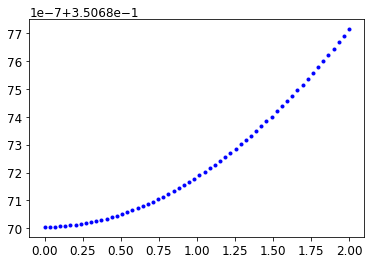

In [11]:
# mean squared error
from sklearn.metrics import mean_squared_error
mse_ridges =[]
alphaGrid = np.linspace(-0.001, 2.0, 60, dtype=float)
for xi in alphaGrid:
    ridge_reg = Ridge(alpha=xi, solver="auto", tol=0.00001, random_state=42)
    ridge_reg.fit(X, Y)
    Y_pred = ridge_reg.predict(X)
    mse_ridges.append(mean_squared_error(Y, Y_pred))
rmse = np.sqrt(mse_ridges)
    
plt.plot(alphaGrid, rmse, "b.", linewidth=3)

### Lasso regression

/usr/lib64/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2695.217500018107, tolerance: 0.2643891755235723
  model = cd_fast.enet_coordinate_descent(


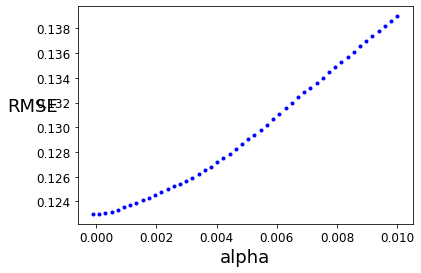

In [15]:
from sklearn.linear_model import Lasso
mse_lasso =[]
alphaGrid = np.linspace(-0.0001, 0.01, 50, dtype=float)
for xi in alphaGrid:
    lasso_reg = Lasso(alpha=xi, max_iter=10000, tol=0.0001,random_state=42, selection='random')
    lasso_reg.fit(X, Y)
    Y_pred = lasso_reg.predict(X)
    mse_lasso.append(mean_squared_error(Y, Y_pred))

rmse_lasso = np.sqrt(mse_lasso)
#plt.figure(figsize=(8,4))
plt.plot(alphaGrid, mse_lasso, "b.", linewidth=3)
plt.xlabel("alpha", rotation=0, fontsize=18)
plt.ylabel("RMSE", rotation=0, fontsize=18)
plt.show()